# WC 2026 - Updated Predictions

Same tournament simulation as `original_predictions.ipynb`, but the match
data is refreshed from the football-data.org API through
`scripts/data_pipeline.py` before the models are refit. Runs with or without
an API key (historical-only when the key is absent).

In [1]:
# Cell 0 - Configuration
import os
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# Make scripts/ importable regardless of where the notebook runs from
sys.path.insert(0, str(Path('..').resolve()))

# Users paste their key here OR set the environment variable.
# Never hardcode a key. Leave the default as an empty string.
FOOTBALL_DATA_API_KEY = os.environ.get("FOOTBALL_DATA_API_KEY", "")

In [2]:
from scripts.data_pipeline import build_master_dataset

print("FOOTBALL_DATA_API_KEY present?", bool(FOOTBALL_DATA_API_KEY), "length:", len(FOOTBALL_DATA_API_KEY))

try:
    _master_test = build_master_dataset(FOOTBALL_DATA_API_KEY or None)
    print("build_master_dataset completed OK, rows:", len(_master_test))
except RuntimeError as e:
    print("RuntimeError from build_master_dataset:")
    print(repr(e))

FOOTBALL_DATA_API_KEY present? True length: 32


C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'World Cup Qualifiers' (WCQ) unavailable for this API key (HTTP 404); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tournament, since_date))
C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'UEFA Nations League' (UNL) unavailable for this API key (HTTP 403); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tournament, since_date))
C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'Copa America' (COPA) unavailable for this API key (HTTP 404); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tournament, since_date))
C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'Africa Cup of Nations' (AFCN) unavailable for this API key (HTTP 404); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tou

New matches added:        5
Last successful API date: 2026-06-28
Total training matches:   49482
  Historical CSV:         49477
  API-added:              11
build_master_dataset completed OK, rows: 49482


In [3]:
import requests

if not FOOTBALL_DATA_API_KEY:
    raise RuntimeError("FOOTBALL_DATA_API_KEY is empty in this kernel/session")

url = "https://api.football-data.org/v4/competitions/WC/matches"
resp = requests.get(
    url,
    headers={"X-Auth-Token": FOOTBALL_DATA_API_KEY},
    params={"status": "FINISHED"},
    timeout=30,
)

print("Status code:", resp.status_code)
print("X-Authenticated-Client:", resp.headers.get("X-Authenticated-Client"))
print("X-RequestsAvailable:", resp.headers.get("X-RequestsAvailable"))
print("X-RequestCounter-Reset:", resp.headers.get("X-RequestCounter-Reset"))
print("Body preview:", resp.text[:300])

Status code: 200
X-Authenticated-Client: Karl
X-RequestsAvailable: None
X-RequestCounter-Reset: 60
Body preview: {"filters":{"season":"2026","status":["FINISHED"]},"resultSet":{"count":73,"first":"2026-06-11","last":"2026-06-28","played":73},"competition":{"id":2000,"name":"FIFA World Cup","code":"WC","type":"CUP","emblem":"https://crests.football-data.org/wm26.png"},"matches":[{"area":{"id":2267,"name":"World


In [4]:
# Cell 1 - Auto-update pipeline
from scripts.data_pipeline import build_master_dataset
import json, pathlib

if FOOTBALL_DATA_API_KEY:
    master = build_master_dataset(FOOTBALL_DATA_API_KEY)
else:
    master = build_master_dataset()   # historical only

# Read and display the update log summary
log_path = pathlib.Path('../data/logs/update_log.json')
if log_path.exists():
    with open(log_path) as f:
        lines = [ln for ln in f.read().splitlines() if ln.strip()]
    last_run = json.loads(lines[-1]) if lines else {}
    print("=== DATA UPDATE SUMMARY ===")
    print(f"New matches added:        {last_run.get('new_matches_added', 0)}")
    print(f"Last API update date:     {last_run.get('last_match_date', 'N/A')}")
    print(f"Total training matches:   {last_run.get('total_matches', 0)}")
    print(f"  Historical CSV:         {last_run.get('n_historical', 0)}")
    print(f"  API-added:              {last_run.get('n_api', 0)}")

C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'World Cup Qualifiers' (WCQ) unavailable for this API key (HTTP 404); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tournament, since_date))
C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'UEFA Nations League' (UNL) unavailable for this API key (HTTP 403); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tournament, since_date))
C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'Copa America' (COPA) unavailable for this API key (HTTP 404); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tournament, since_date))
C:\Users\karle\Downloads\world-cup-predictor\scripts\data_pipeline.py:341: UserWarning: Competition 'Africa Cup of Nations' (AFCN) unavailable for this API key (HTTP 404); skipping.
  all_rows.extend(_fetch_competition(api_key, code, tou

New matches added:        1
Last successful API date: 2026-06-28
Total training matches:   49478
  Historical CSV:         49477
  API-added:              3
=== DATA UPDATE SUMMARY ===
New matches added:        1
Last API update date:     2026-06-28
Total training matches:   49478
  Historical CSV:         49477
  API-added:              3


Imports OK
results.csv   : 49,478 rows
shootouts.csv : 677 rows

All unique tournament values (first 20 shown):
['ABCS Tournament', 'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification', 'AFC Solidarity Cup', 'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 'ASEAN Championship qualification', 'African Cup of Nations', 'African Cup of Nations qualification', 'African Friendship Games', 'Afro-Asian Games', 'Al Ain International Cup', 'All-African Games', 'Amílcar Cabral Cup', 'Arab Cup', 'Arab Cup qualification', 'Asian Games'] ...
Dropped 70 rows with missing scores

After removing Friendlies + missing scores: 31,022 rows
Remaining tournament types (first 30):
['ABCS Tournament', 'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification', 'AFC Solidarity Cup', 'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 'ASEAN Championship qualification'

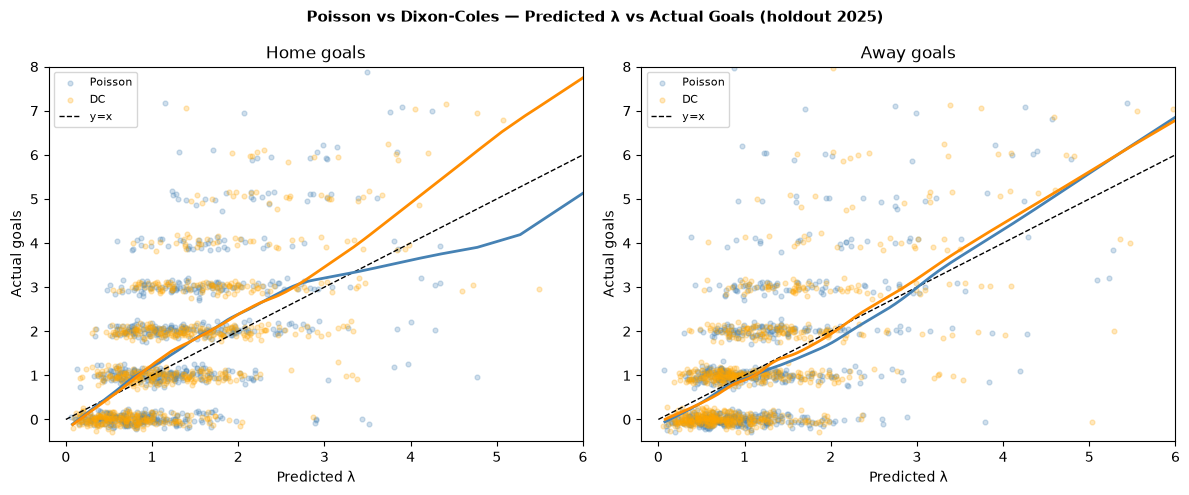


DC model globals restored.
INTEGRATION TESTS — Dixon-Coles Model

--- Expected Goals & Win Probabilities ---
Match                           neut   λ_home  λ_away    P(hw) P(draw)   P(aw)
------------------------------------------------------------------------------
France vs Argentina             True    0.630   1.497    0.156   0.261   0.583
Spain vs Brazil                 True    1.272   1.167    0.389   0.274   0.338
Germany vs England              True    0.855   1.357    0.236   0.278   0.485
USA vs Mexico                  False    0.859   1.023    0.297   0.318   0.385

--- Group match (draw inflation applied) ---
Match                           neut   HG  AG  Result
-------------------------------------------------------
France vs Argentina             True    0   1  Argentina
Spain vs Brazil                 True    1   1  Draw
Germany vs England              True    0   1  England
USA vs Mexico                  False    0   1  Mexico

--- Knockout (no draws, renormalized) ---

In [5]:
# Cell 2 - Load and refit models on the freshly updated dataset.
# Running dc_model.ipynb exposes the prediction API
# (predict_group_match, predict_knockout_winner, predict_winner, get_elo, ...)
# used by the simulation below. This notebook is DC-only (not ensemble_model.ipynb).
%run ../models/dc_model.ipynb

# FIFA World Cup 2026: Full Tournament Predictions
By Karl Estampador :)

Simulates all 104 matches using the Elo-based model from whatever model is selected.  
The higher-Elo team always advances.  
Third-place bracket allocation follows FIFA's official 495-combination lookup table.

In [6]:
import pandas as pd
from pathlib import Path
from scripts.data_pipeline import standardise_team_name

DATA = Path('../data/tournament')

# Load schedule and team registry
matches_df = pd.read_csv(DATA / 'matches.csv')
teams_df   = pd.read_csv(DATA / 'teams.csv')

# Build team-ID -> name lookup
id_to_name: dict[int, str] = dict(zip(teams_df['id'], teams_df['team_name']))
name_to_group: dict[str, str] = dict(zip(teams_df['team_name'], teams_df['group_letter']))

alloc_df = pd.read_csv(DATA / 'third_place_allocation.csv')

# Reverse lookup: canonical name (as returned by standardise_team_name) -> teams.csv name
# e.g. "United States" -> "USA", "Ivory Coast" -> "Côte d'Ivoire", "Iran" -> "IR Iran"
canonical_to_csv: dict[str, str] = {
    standardise_team_name(name): name for name in id_to_name.values()
}

print(f'{len(matches_df)} matches loaded | {len(teams_df)} teams | allocation table: {len(alloc_df)} rows')

104 matches loaded | 48 teams | allocation table: 495 rows


In [7]:
import requests
import json as _json
import time as _time

# #region agent log
def _agent_log_api(message, data, hypothesis_id):
    _entry = {
        "sessionId": "4e5c31",
        "timestamp": int(_time.time() * 1000),
        "location": "updated_predictions.ipynb:api_load",
        "message": message,
        "data": data,
        "hypothesisId": hypothesis_id,
        "runId": "pre-fix",
    }
    with open(Path("../debug-4e5c31.log"), "a", encoding="utf-8") as _lf:
        _lf.write(_json.dumps(_entry) + "\n")
# #endregion

# Fetch all FINISHED WC 2026 matches from the API and store them for use in
# the group-stage and knockout simulations below.  When a match is found here
# the actual score is used instead of a model prediction.
# wc2026_completed: frozenset({team_a, team_b}) -> {home, away, home_score, away_score, winner}
wc2026_completed: dict = {}

if FOOTBALL_DATA_API_KEY:
    _resp = requests.get(
        "https://api.football-data.org/v4/competitions/WC/matches",
        headers={"X-Auth-Token": FOOTBALL_DATA_API_KEY},
        params={"status": "FINISHED"},
        timeout=30,
    )
    if _resp.status_code == 200:
        for _m in _resp.json().get("matches", []):
            # Normalise API name -> canonical -> teams.csv name
            _raw_ht, _raw_at = _m["homeTeam"]["name"], _m["awayTeam"]["name"]
            _canon_ht, _canon_at = standardise_team_name(_raw_ht), standardise_team_name(_raw_at)
            _ht = canonical_to_csv.get(_canon_ht)
            _at = canonical_to_csv.get(_canon_at)
            # #region agent log
            if not _ht or not _at:
                _agent_log_api(
                    "API match skipped: team name not mapped to teams.csv",
                    {
                        "raw_home": _raw_ht,
                        "raw_away": _raw_at,
                        "canon_home": _canon_ht,
                        "canon_away": _canon_at,
                        "mapped_home": _ht,
                        "mapped_away": _at,
                        "match_id": _m.get("id"),
                    },
                    "H1",
                )
            elif "verde" in _raw_ht.lower() or "verde" in _raw_at.lower():
                _agent_log_api(
                    "Cabo/Cape Verde match mapped",
                    {
                        "raw_home": _raw_ht,
                        "raw_away": _raw_at,
                        "canon_home": _canon_ht,
                        "canon_away": _canon_at,
                        "mapped_home": _ht,
                        "mapped_away": _at,
                    },
                    "H1",
                )
            # #endregion
            if not _ht or not _at:
                continue
            _hs = _m["score"]["fullTime"]["home"]
            _as = _m["score"]["fullTime"]["away"]
            if _hs is None or _as is None:
                continue
            # score.winner reflects the ultimate winner (including ET / penalties)
            _raw_winner = _m["score"].get("winner")
            _winner = _ht if _raw_winner == "HOME_TEAM" else (_at if _raw_winner == "AWAY_TEAM" else None)
            wc2026_completed[frozenset({_ht, _at})] = {
                "home":       _ht,
                "away":       _at,
                "home_score": int(_hs),
                "away_score": int(_as),
                "winner":     _winner,
            }
        print(f"Loaded {len(wc2026_completed)} completed WC 2026 matches from API")
    else:
        print(f"API returned HTTP {_resp.status_code} — all matches will be predicted")
else:
    print("No API key set — all matches will be predicted")

Loaded 73 completed WC 2026 matches from API


---
## 1. Group Stage Simulation

In [8]:
group_matches = matches_df[matches_df['stage_id'] == 1].copy()

gs_results = []   # list of dicts, one per group-stage match

for _, row in group_matches.iterrows():
    home = id_to_name[int(row['home_team_id'])]
    away = id_to_name[int(row['away_team_id'])]

    actual = wc2026_completed.get(frozenset({home, away}))
    # #region agent log
    if "Cabo Verde" in (home, away):
        _agent_log_api(
            "Group-stage Cabo Verde lookup",
            {"home": home, "away": away, "found_actual": actual is not None, "actual": actual},
            "H2",
        )
    # #endregion
    if actual:
        hg, ag = actual['home_score'], actual['away_score']
        # Flip scores if the API listed the teams in the opposite order
        if actual['home'] != home:
            hg, ag = ag, hg
        winner = home if hg > ag else (away if ag > hg else 'Draw')
        source = 'actual'
    else:
        hg, ag, _w = predict_group_match(home, away)
        winner = _w if _w else 'Draw'
        source = 'predicted'

    gs_results.append({
        'match':      int(row['match_number']),
        'group':      row['match_label'],
        'home':       home,
        'away':       away,
        'home_goals': hg,
        'away_goals': ag,
        'winner':     winner,
        'source':     source,
    })

gs_df = pd.DataFrame(gs_results)
actual_count    = (gs_df['source'] == 'actual').sum()
predicted_count = (gs_df['source'] == 'predicted').sum()
print(f'{len(gs_df)} group-stage matches: {actual_count} actual results, {predicted_count} predicted')

72 group-stage matches: 72 actual results, 0 predicted


### Group Stage Results

In [9]:
display_gs = gs_df[['match','group','home','home_goals','away_goals','away','winner','source']].copy()
display_gs.columns = ['Match','Group','Home','HG','AG','Away','Winner','Source']

pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 30)

display_gs

,Match,Group,Home,HG,AG,Away,Winner,Source
0,1,Group A,Mexico,2,0,South Africa,Mexico,actual
1,2,Group A,South Korea,2,1,Czechia,South Korea,actual
2,3,Group B,Canada,1,1,Bosnia and Herzegovina,Draw,actual
3,4,Group D,USA,4,1,Paraguay,USA,actual
4,5,Group B,Qatar,1,1,Switzerland,Draw,actual
5,6,Group C,Brazil,1,1,Morocco,Draw,actual
6,7,Group C,Haiti,0,1,Scotland,Scotland,actual
7,8,Group D,Australia,2,0,Turkey,Australia,actual
8,9,Group E,Germany,7,1,Curaçao,Germany,actual
9,10,Group F,Netherlands,2,2,Japan,Draw,actual


---
## 2. Group Standings

In [10]:
# build standings table for all 12 groups from group-stage results
def build_standings(gs_df: pd.DataFrame) -> pd.DataFrame:
    """
    Tiebreakers (when points equal):
      1. Head-to-head points among tied teams
      2. Goal difference (all group games)
      3. Goals scored (all group games)
      4. Elo rating (proxy for FIFA rank)
    """
    stats: dict[str, dict] = {}
    h2h: dict[tuple, int] = {}  # (team_a, team_b) -> pts earned by team_a

    for _, r in gs_df.iterrows():
        h, a = r['home'], r['away']
        hg, ag = int(r['home_goals']), int(r['away_goals'])
        if hg > ag:
            h2h[(h, a)], h2h[(a, h)] = 3, 0
        elif hg == ag:
            h2h[(h, a)], h2h[(a, h)] = 1, 1
        else:
            h2h[(h, a)], h2h[(a, h)] = 0, 3
        for team, gf, ga in [
            (r['home'], r['home_goals'], r['away_goals']),
            (r['away'], r['away_goals'], r['home_goals']),
        ]:
            if team not in stats:
                stats[team] = {'gp': 0, 'w': 0, 'd': 0, 'l': 0, 'gf': 0, 'ga': 0, 'pts': 0}
            s = stats[team]
            s['gp'] += 1
            s['gf'] += gf
            s['ga'] += ga
            if gf > ga:
                s['w']   += 1
                s['pts'] += 3
            elif gf == ga:
                s['d']   += 1
                s['pts'] += 1
            else:
                s['l'] += 1

    rows = []
    for team, s in stats.items():
        rows.append({
            'team':  team,
            'group': name_to_group[team],
            'gp':    s['gp'],
            'w':     s['w'],
            'd':     s['d'],
            'l':     s['l'],
            'gf':    s['gf'],
            'ga':    s['ga'],
            'gd':    s['gf'] - s['ga'],
            'pts':   s['pts'],
            'elo':   get_elo(team),
        })

    df = pd.DataFrame(rows)

    def calc_h2h_pts(team, opponents):
        return sum(h2h.get((team, opp), 0) for opp in opponents)

    ranked = []
    for _, grp in df.groupby('group'):
        grp = grp.sort_values('pts', ascending=False).reset_index(drop=True)
        tiers = []
        for _, tied in grp.groupby('pts', sort=False):
            if len(tied) == 1:
                tiers.append(tied)
            else:
                tied_teams = tied['team'].tolist()
                tied = tied.copy()
                tied['h2h_pts'] = tied['team'].apply(
                    lambda t: calc_h2h_pts(t, [x for x in tied_teams if x != t])
                )
                tied = tied.sort_values(
                    ['h2h_pts', 'gd', 'gf', 'elo'],
                    ascending=[False, False, False, False]
                ).drop(columns='h2h_pts')
                tiers.append(tied)
        ranked.append(pd.concat(tiers))

    df = pd.concat(ranked).reset_index(drop=True)

    # Add rank within group (1-4)
    df['rank'] = df.groupby('group').cumcount() + 1
    return df


standings = build_standings(gs_df)
print(standings[['group','rank','team','gp','w','d','l','gf','ga','gd','pts','elo']].to_string(index=False))

group  rank                   team  gp  w  d  l  gf  ga  gd  pts  elo
    A     1                 Mexico   3  3  0  0   6   0   6    9 1860
    A     2           South Africa   3  1  1  1   2   3  -1    4 1524
    A     3            South Korea   3  1  0  2   2   3  -1    3 1752
    A     4                Czechia   3  0  1  2   2   6  -4    1 1726
    B     1            Switzerland   3  2  1  0   7   3   4    7 1889
    B     2                 Canada   3  1  1  1   8   3   5    4 1784
    B     3 Bosnia and Herzegovina   3  1  1  1   5   6  -1    4 1594
    B     4                  Qatar   3  0  1  2   2  10  -8    1 1425
    C     1                 Brazil   3  2  1  0   7   1   6    7 1984
    C     2                Morocco   3  2  1  0   6   3   3    7 1822
    C     3               Scotland   3  1  0  2   1   4  -3    3 1767
    C     4                  Haiti   3  0  0  3   2   8  -6    0 1532
    D     1                    USA   3  2  0  1   8   4   4    6 1721
    D     2         

### Group Standings Summary (Qualification Status)

In [11]:
def qualify_label(rank: int, team: str, qualified_thirds: set) -> str:
    if rank == 1:
        return '✓ 1st'
    elif rank == 2:
        return '✓ 2nd'
    elif rank == 3:
        return '? 3rd'
    else:
        return '✗ Out'

disp = standings[['group','rank','team','pts','gd','gf','elo']].copy()
disp['status'] = disp['rank'].map({1:'✓ 1st', 2:'✓ 2nd', 3:'→ TBD 3rd', 4:'✗ Eliminated'})
disp.columns = ['Group','Rank','Team','Pts','GD','GF','Elo','Status']
disp

,Group,Rank,Team,Pts,GD,GF,Elo,Status
0,A,1,Mexico,9,6,6,1860,✓ 1st
1,A,2,South Africa,4,-1,2,1524,✓ 2nd
2,A,3,South Korea,3,-1,2,1752,→ TBD 3rd
3,A,4,Czechia,1,-4,2,1726,✗ Eliminated
4,B,1,Switzerland,7,4,7,1889,✓ 1st
5,B,2,Canada,4,5,8,1784,✓ 2nd
6,B,3,Bosnia and Herzegovina,4,-1,5,1594,→ TBD 3rd
7,B,4,Qatar,1,-8,2,1425,✗ Eliminated
8,C,1,Brazil,7,6,7,1984,✓ 1st
9,C,2,Morocco,7,3,6,1822,✓ 2nd


---
## 3. Third-Place Team Ranking

All 12 third-place finishers are ranked by: points → GD → GF → Elo.  
The top 8 advance to the Round of 32.

In [12]:
thirds = standings[standings['rank'] == 3].sort_values(
    ['pts', 'gd', 'gf', 'elo'],
    ascending=[False, False, False, False]
).reset_index(drop=True)

thirds['third_rank'] = range(1, len(thirds) + 1)
thirds['advances'] = thirds['third_rank'] <= 8

print('All third-place teams ranked (top 8 advance):\n')
display_thirds = thirds[['third_rank','group','team','pts','gd','gf','elo','advances']].copy()
display_thirds.columns = ['Rank','Group','Team','Pts','GD','GF','Elo','Advances']
display_thirds

All third-place teams ranked (top 8 advance):



,Rank,Group,Team,Pts,GD,GF,Elo,Advances
0,1,K,DR Congo,4,1,4,1655,True
1,2,F,Sweden,4,0,7,1719,True
2,3,E,Ecuador,4,0,2,1933,True
3,4,L,Ghana,4,0,2,1503,True
4,5,B,Bosnia and Herzegovina,4,-1,5,1594,True
5,6,J,Algeria,4,-2,5,1743,True
6,7,D,Paraguay,4,-2,2,1833,True
7,8,I,Senegal,3,2,8,1878,True
8,9,G,IR Iran,3,0,3,1760,False
9,10,A,South Korea,3,-1,2,1752,False


---
## 4. Third-Place Bracket Allocation

The 8 qualifying group letters are sorted and looked up in FIFA's official 495-row allocation table, which assigns each third-place team to a specific Round of 32 slot.

In [13]:
# The 8 advancing third-place teams and their groups
qualifying_thirds = thirds[thirds['advances']]
qualifying_groups_letters = sorted(qualifying_thirds['group'].tolist())
combo_key = ''.join(qualifying_groups_letters)

print(f'Qualifying third-place groups: {qualifying_groups_letters}')
print(f'Combination key: {combo_key}')

alloc_row = alloc_df[alloc_df['qualifying_groups'] == combo_key]

if alloc_row.empty:
    raise ValueError(f'No allocation row found for combination: {combo_key}')

alloc_row = alloc_row.iloc[0]

# Map: match_number -> which group's 3rd-place team plays there
third_slot: dict[int, str] = {}
for col in ['match_74', 'match_77', 'match_79', 'match_80', 'match_81', 'match_82', 'match_85', 'match_87']:
    match_num = int(col.split('_')[1])
    group_letter = alloc_row[col].replace('3', '')
    third_slot[match_num] = group_letter

# Build lookup: group letter → team name (for qualifying thirds)
group_to_third_team: dict[str, str] = dict(zip(qualifying_thirds['group'], qualifying_thirds['team']))

# prints the third place match assignments
print('\nThird-place match assignments:')
for match_num, grp in sorted(third_slot.items()):
    team = group_to_third_team.get(grp, f'[Group {grp} 3rd]')
    print(f'  Match {match_num}: 3rd place from Group {grp} → {team}')

Qualifying third-place groups: ['B', 'D', 'E', 'F', 'I', 'J', 'K', 'L']
Combination key: BDEFIJKL

Third-place match assignments:
  Match 74: 3rd place from Group D → Paraguay
  Match 77: 3rd place from Group F → Sweden
  Match 79: 3rd place from Group E → Ecuador
  Match 80: 3rd place from Group K → DR Congo
  Match 81: 3rd place from Group I → Senegal
  Match 82: 3rd place from Group B → Bosnia and Herzegovina
  Match 85: 3rd place from Group J → Algeria
  Match 87: 3rd place from Group L → Ghana


---
## 5. Knockout Bracket Simulation

Round of 32 → Round of 16 → Quarterfinals → Semifinals → Bronze Final → Final

In [14]:
import re

# returns the team that finished in position `rank` in the given group
def get_group_finisher(rank: int, group: str) -> str:
    result = standings[(standings['group'] == group) & (standings['rank'] == rank)]
    if result.empty:
        raise ValueError(f'No rank-{rank} team in group {group}')
    return result.iloc[0]['team']

# resolves a bracket token like '1A' into a concrete team name
def resolve_team(token: str,
                 match_winners: dict[int, str],
                 match_losers: dict[int, str]) -> str:
    # Winner of match N
    m = re.match(r'^W(\d+)$', token)
    if m:
        mn = int(m.group(1))
        return match_winners[mn]

    # Runner-up (loser) of match N
    m = re.match(r'^RU(\d+)$', token)
    if m:
        mn = int(m.group(1))
        return match_losers[mn]

    # Group finisher: '1A', '2F', etc.
    m = re.match(r'^([12])([A-L])$', token)
    if m:
        return get_group_finisher(int(m.group(1)), m.group(2))

    # Third-place slot: '3ABCDF' (match number determines which group's 3rd)
    # The calling code handles this separately via third_slot
    raise ValueError(f'Cannot resolve token: {token}')


def parse_label_tokens(label: str) -> tuple[str, str]:
    """Split a match_label like '1E vs 3ABCDF' into two raw tokens."""
    parts = label.strip().split(' vs ')
    if len(parts) != 2:
        raise ValueError(f'Unexpected label format: {label}')
    return parts[0].strip(), parts[1].strip()


# Run knockout bracket
match_winners: dict[int, str] = {}   # match_number -> winner team name
match_losers:  dict[int, str] = {}   # match_number-> loser team name (for bronze)

ko_matches = matches_df[matches_df['stage_id'] >= 2].sort_values('match_number')

stage_names = {2: 'Round of 32', 3: 'Round of 16', 4: 'Quarterfinals',
               5: 'Semifinals', 6: 'Bronze Final', 7: 'Final'}

ko_results = []

for _, row in ko_matches.iterrows():
    mn    = int(row['match_number'])
    stage = int(row['stage_id'])
    label = row['match_label']

    tok_a, tok_b = parse_label_tokens(label)

    # Resolve third-place tokens (e.g. '3ABCDF') using allocation table
    def resolve_with_third(tok):
        if re.match(r'^3[A-L]+$', tok):
            grp = third_slot[mn]
            return group_to_third_team[grp]
        return resolve_team(tok, match_winners, match_losers)

    team_a = resolve_with_third(tok_a)
    team_b = resolve_with_third(tok_b)

    actual = wc2026_completed.get(frozenset({team_a, team_b}))
    if actual:
        winner = actual['winner']
        # Fallback: use goals if score.winner was absent
        if winner is None:
            hg, ag = actual['home_score'], actual['away_score']
            if actual['home'] == team_a:
                winner = team_a if hg > ag else team_b
            else:
                winner = team_b if hg > ag else team_a
        loser  = team_b if winner == team_a else team_a
        w_prob = 1.0
        source = 'actual'
        hg, ag = actual['home_score'], actual['away_score']
        if actual['home'] != team_a:
            hg, ag = ag, hg
    else:
        winner, loser, w_prob, l_prob = predict_knockout_winner(team_a, team_b)
        hg, ag, _ = predict_group_match(team_a, team_b)
        source = 'predicted'

    match_winners[mn] = winner
    match_losers[mn]  = loser

    ko_results.append({
        'match':    mn,
        'stage':    stage_names[stage],
        'team_a':   team_a,
        'team_b':   team_b,
        'home_goals': hg,
        'away_goals': ag,
        'winner':   winner,
        'loser':    loser,
        'win_prob': round(w_prob, 3),
        'lose_prob': round(1.0 - w_prob, 3),
        'source':   source,
    })

ko_df = pd.DataFrame(ko_results)
print(f'{len(ko_df)} knockout matches resolved')

32 knockout matches resolved


---
## 6. Results Output

### Round of 32

In [15]:
# show_stage shows the result of every match
def show_stage(stage_name: str):
    df = ko_df[ko_df['stage'] == stage_name][['match','team_a','home_goals','away_goals','team_b','winner','win_prob']].copy()
    df.columns = ['Match', 'Team A', 'HG', 'AG', 'Team B', 'Winner', 'Win Prob']
    return df.reset_index(drop=True)

show_stage('Round of 32')

,Match,Team A,HG,AG,Team B,Winner,Win Prob
0,73,South Africa,0,1,Canada,Canada,1.000
1,74,Germany,1,0,Paraguay,Germany,0.557
2,75,Netherlands,0,1,Morocco,Morocco,0.774
3,76,Brazil,0,1,Japan,Japan,0.605
4,77,France,1,0,Sweden,France,0.822
5,78,Côte d'Ivoire,1,1,Norway,Norway,0.601
6,79,Mexico,0,0,Ecuador,Mexico,0.606
7,80,England,1,0,DR Congo,England,0.790
8,81,USA,1,0,Senegal,USA,0.630
9,82,Belgium,2,0,Bosnia and Herzegovina,Belgium,0.876


### Round of 16

In [16]:
show_stage('Round of 16')

,Match,Team A,HG,AG,Team B,Winner,Win Prob
0,89,Canada,0,1,Morocco,Morocco,0.639
1,90,Germany,1,1,France,France,0.528
2,91,Japan,2,0,Norway,Japan,0.814
3,92,Mexico,0,0,England,Mexico,0.566
4,93,Portugal,1,1,Spain,Spain,0.672
5,94,USA,1,0,Belgium,USA,0.749
6,95,Argentina,0,0,Australia,Argentina,0.573
7,96,Switzerland,0,1,Colombia,Colombia,0.760


### Quarterfinals

In [17]:
show_stage('Quarterfinals')

,Match,Team A,HG,AG,Team B,Winner,Win Prob
0,97,Morocco,1,0,France,Morocco,0.690
1,98,Spain,1,1,USA,Spain,0.577
2,99,Japan,0,0,Mexico,Mexico,0.502
3,100,Argentina,1,0,Colombia,Argentina,0.711


### Semifinals

In [18]:
show_stage('Semifinals')

,Match,Team A,HG,AG,Team B,Winner,Win Prob
0,101,Morocco,0,0,Spain,Morocco,0.562
1,102,Mexico,0,0,Argentina,Argentina,0.596


### Bronze Final (3rd Place)

In [19]:
show_stage('Bronze Final')

,Match,Team A,HG,AG,Team B,Winner,Win Prob
0,103,Spain,0,1,Mexico,Mexico,0.572


---
## 🏆 Final

In [20]:
final_row = ko_df[ko_df['stage'] == 'Final'].iloc[0]
champion  = final_row['winner']
runner_up = final_row['loser']

print('=' * 60)
print(f'  FINAL  (Match {final_row["match"]})')
print(f'  {final_row["team_a"]:25s} {final_row["home_goals"]}-{final_row["away_goals"]}  vs  {final_row["team_b"]}')
print(f'  Winner:     {champion}')
print(f'  Runner-up:  {runner_up}')
print('=' * 60)
print(f'\n  2026 FIFA WORLD CUP CHAMPION: {champion.upper()}')
print(f'  (Elo: {get_elo(champion):.0f} | Win prob in final: {final_row["win_prob"]:.1%})')

  FINAL  (Match 104)
  Morocco                   0-0  vs  Argentina
  Winner:     Argentina
  Runner-up:  Morocco

  2026 FIFA WORLD CUP CHAMPION: ARGENTINA
  (Elo: 2113 | Win prob in final: 60.2%)


---
## Full Knockout Bracket Summary

In [21]:
for stage in ['Round of 32', 'Round of 16', 'Quarterfinals', 'Semifinals', 'Bronze Final', 'Final']:
    subset = ko_df[ko_df['stage'] == stage]
    print(f'\n{stage.upper()}')
    print('-' * 60)
    for _, r in subset.iterrows():
        print(f'  Match {r["match"]:3d}: {r["team_a"]:26s} {r["home_goals"]}-{r["away_goals"]} {r["team_b"]:26s}  →  {r["winner"]}')


ROUND OF 32
------------------------------------------------------------
  Match  73: South Africa               0-1 Canada                      →  Canada
  Match  74: Germany                    1-0 Paraguay                    →  Germany
  Match  75: Netherlands                0-1 Morocco                     →  Morocco
  Match  76: Brazil                     0-1 Japan                       →  Japan
  Match  77: France                     1-0 Sweden                      →  France
  Match  78: Côte d'Ivoire              1-1 Norway                      →  Norway
  Match  79: Mexico                     0-0 Ecuador                     →  Mexico
  Match  80: England                    1-0 DR Congo                    →  England
  Match  81: USA                        1-0 Senegal                     →  USA
  Match  82: Belgium                    2-0 Bosnia and Herzegovina      →  Belgium
  Match  83: Portugal                   1-0 Croatia                     →  Portugal
  Match  84: Spain    

In [22]:
import os
from pathlib import Path

try:
    from dotenv import load_dotenv
    print("dotenv available")
    load_dotenv(dotenv_path=Path("..") / ".env")
    print(".env loaded from:", (Path("..") / ".env").resolve())
except ImportError:
    print("python-dotenv not installed")

FOOTBALL_DATA_API_KEY = os.environ.get("FOOTBALL_DATA_API_KEY", "")
print("Key loaded?", bool(FOOTBALL_DATA_API_KEY), "Length:", len(FOOTBALL_DATA_API_KEY))
print("First 5 chars (for sanity, not full key):", FOOTBALL_DATA_API_KEY[:5])

dotenv available
.env loaded from: C:\Users\karle\Downloads\world-cup-predictor\.env
Key loaded? True Length: 32
First 5 chars (for sanity, not full key): 340d5


In [23]:
import requests

if not FOOTBALL_DATA_API_KEY:
    raise RuntimeError("FOOTBALL_DATA_API_KEY is empty in this kernel/session")

url = "https://api.football-data.org/v4/competitions/WC/matches"
resp = requests.get(
    url,
    headers={"X-Auth-Token": FOOTBALL_DATA_API_KEY},
    params={"status": "FINISHED"},
    timeout=30,
)

print("Status code:", resp.status_code)
print("Sample of response text:", resp.text[:200])

if resp.status_code == 200:
    data = resp.json()
    print("Keys:", list(data.keys()))
    print("Number of matches:", len(data.get("matches", [])))
elif resp.status_code in (401, 403):
    print("Auth error — key invalid or not authorized for this endpoint.")

Status code: 200
Sample of response text: {"filters":{"season":"2026","status":["FINISHED"]},"resultSet":{"count":73,"first":"2026-06-11","last":"2026-06-28","played":73},"competition":{"id":2000,"name":"FIFA World Cup","code":"WC","type":"CU
Keys: ['filters', 'resultSet', 'competition', 'matches']
Number of matches: 73
